In [8]:
pip install mlxtend


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 7.8 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.4 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.3 MB 1.7 MB/s eta 0:00:05
   ---------------- ----------------------- 3.9/9.3 MB 5.2 MB/s eta 0:00:02
   ------------------------------- -------- 7.3/9.3 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 8.0 MB/s  0:00:01
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------- ----------------------------- 3.4/12

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.4.6 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

## Displaying the First Five Rows and Loading dataset

In [2]:
df = pd.read_csv("Groceries_dataset_excel.csv")
print(df.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


## Understanding the Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


## Checking Missing Values

In [4]:
df.isnull().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

## Checking duplicates

In [5]:
df.duplicated().sum()

759

In [6]:
print(df[df.duplicated()].head())

      Member_number        Date   itemDescription
5015           2051  11-09-2015       frankfurter
5022           3055  18-08-2015  other vegetables
5044           1994  11-03-2015        whole milk
5055           1682  25-06-2015         pip fruit
5059           4324  05-01-2015           sausage


In [7]:
df[df.duplicated(keep=False)].sort_values(
    by=['Member_number', 'Date', 'itemDescription']
)

,Member_number,Date,itemDescription
33098,1003,27-02-2014,rolls/buns
37649,1003,27-02-2014,rolls/buns
15099,1005,09-01-2014,rolls/buns
31248,1005,09-01-2014,rolls/buns
7532,1006,14-06-2015,frankfurter
...,...,...,...
24043,4981,10-01-2015,margarine
8109,4988,29-10-2015,rolls/buns
24258,4988,29-10-2015,rolls/buns
33585,4992,24-02-2014,margarine


## Removing Duplicate Records

In [8]:
df = df.drop_duplicates()

In [9]:
print(df.shape)
print(df.head())
print(df.isnull().sum())

(38006, 3)
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk
Member_number      0
Date               0
itemDescription    0
dtype: int64


## Grouping Purchased Items into Customer Transactions

In [10]:
basket = df.groupby(
    ['Member_number', 'Date']
)['itemDescription'].apply(list).reset_index()

basket.head()

,Member_number,Date,itemDescription
0,1000,15-03-2015,"[sausage, whole milk, semi-finished bread, yog..."
1,1000,24-06-2014,"[whole milk, pastry, salty snack]"
2,1000,24-07-2015,"[canned beer, misc. beverages]"
3,1000,25-11-2015,"[sausage, hygiene articles]"
4,1000,27-05-2015,"[soda, pickled vegetables]"


## Converting Transactions into a List

In [11]:
transactions=basket['itemDescription'].tolist()
print(transactions[:5])

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles'], ['soda', 'pickled vegetables']]


## Applying One-Hot Encoding using TransactionEncoder

In [15]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket_encoded = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print(basket_encoded.shape)
basket_encoded.head()

(14963, 167)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Applying the Apriori Algorithm

In [16]:
from mlxtend.frequent_patterns import apriori
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])

Total Frequent Itemsets: 69


## Generating Association Rules

In [17]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 1) & rules['consequents'].apply(lambda x: len(x) >= 1)]
print("Association Rules:", rules.shape[0])
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

Association Rules: 4
          antecedents   consequents   support  confidence      lift
0  (other vegetables)  (whole milk)  0.014837    0.121511  0.769430
1        (rolls/buns)  (whole milk)  0.013968    0.126974  0.804028
2              (soda)  (whole milk)  0.011629    0.119752  0.758296
3            (yogurt)  (whole milk)  0.011161    0.129961  0.822940


## showing result of top 10 Most Purchased Items

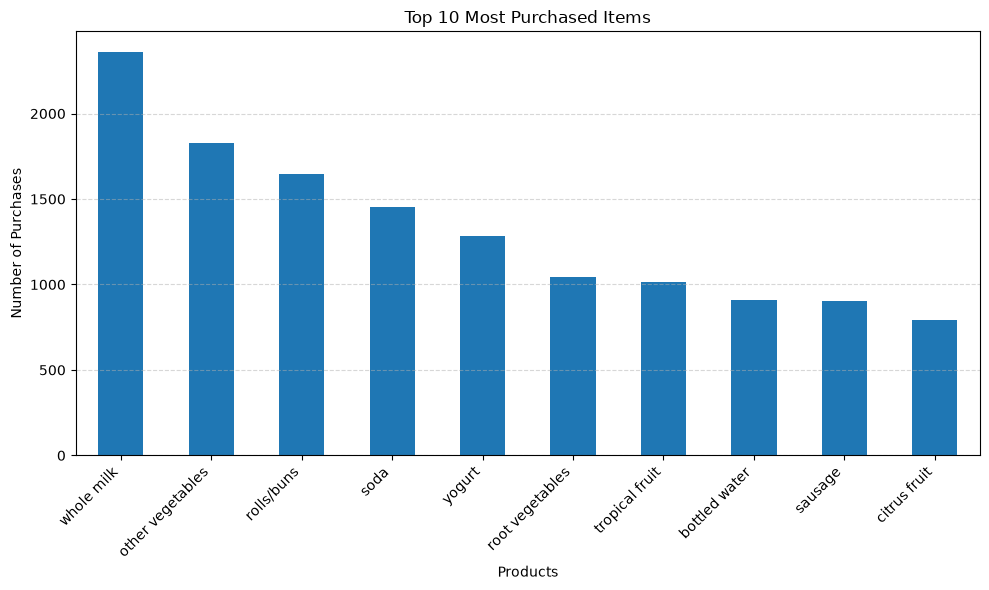

In [19]:
import matplotlib.pyplot as plt

top_items = df['itemDescription'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_items.plot(kind='bar')

plt.title("Top 10 Most Purchased Items")
plt.xlabel("Products")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

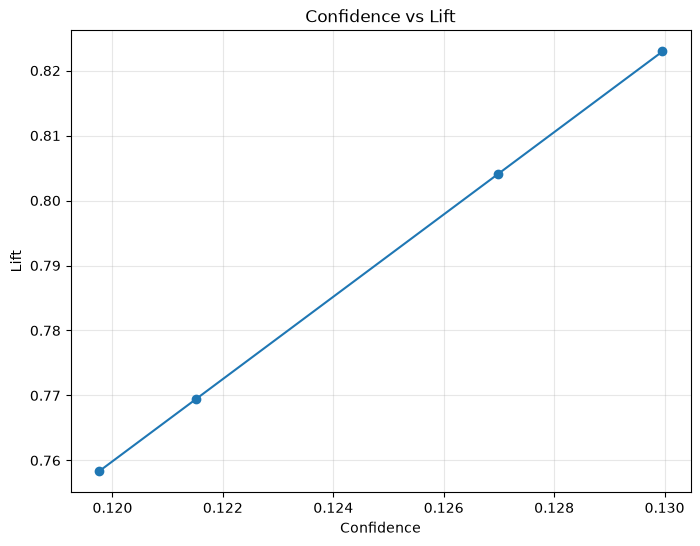

In [22]:
rules_sorted = rules.sort_values(by='confidence')
plt.figure(figsize=(8,6))

plt.plot(
    rules_sorted['confidence'],
    rules_sorted['lift'],
    marker='o',
    linestyle='-'
)

plt.title("Confidence vs Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")

plt.grid(alpha=0.3)

plt.show()